<a href="https://colab.research.google.com/github/miguelpoquini-eng/AVALIACAO-N1-MACHINE-LEARNING/blob/main/ML_Recomendacao_Roupas_COMPLETO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Aprendizado de Máquina Supervisionado para Negócios
## Sistema de Recomendação de Roupas com Filtragem Colaborativa

| Campo | Informação |
|---|---|
| **Disciplina** | Aprendizado de Máquina |
| **Algoritmo** | Item-Based Collaborative Filtering (Similaridade Cosseno) |
| **Dataset** | E-commerce de Roupas (gerado sinteticamente) |
| **Ambiente** | Google Colab / Python 3 |

---
### 📋 Estrutura do Notebook

1. Instalação e Importação de Bibliotecas  
2. **Artefato 1** — Coleta, Limpeza e Normalização dos Dados  
3. **Artefato 2** — Divisão Treino/Teste e Desenvolvimento do Modelo  
4. **Artefato 3** — Avaliação com Métricas e Função de Recomendação  
5. **Artefato 4** — Visualizações dos Resultados  
6. **Artefato 5** — Matriz de Confusão (Classificação Binária de Relevância)  
7. **Artefato 6** — Relatório e Reflexão Crítica  


## 1. Instalação e Importação de Bibliotecas

In [1]:
print("🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score,
    recall_score, f1_score, accuracy_score
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

print("✅ Todas as bibliotecas foram importadas com sucesso!")


🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!
✅ Todas as bibliotecas foram importadas com sucesso!


## 2. Artefato 1 — Coleta, Limpeza e Normalização dos Dados

> **Conceito:** Antes de treinar qualquer modelo, os dados precisam ser coletados, inspecionados e tratados.  
> Valores ausentes distorcem os algoritmos; a normalização garante que variáveis em escalas diferentes não dominem o aprendizado.


📦 ARTEFATO 1 — Coleta e Limpeza de Dados
🔍 Verificação Inicial
Total de registros : 535
Valores nulos      : 10
✅ Nulos tratados com mediana (3.0)


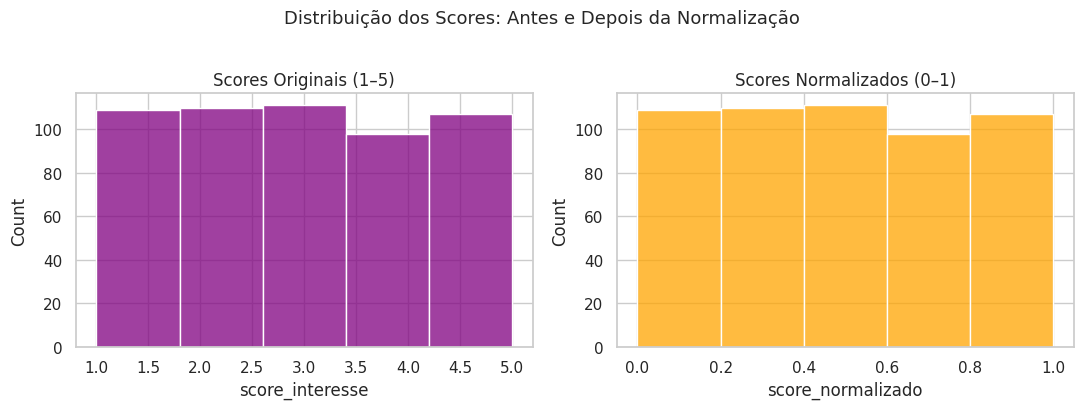


✅ Dados limpos e normalizados com sucesso!


In [2]:
print("=" * 60)
print("📦 ARTEFATO 1 — Coleta e Limpeza de Dados")
print("=" * 60)

# ── Geração do dataset sintético de e-commerce ──────────────────────────────
usuarios = [f"User_{i}" for i in range(1, 101)]   # 100 usuários
produtos = [
    "Camiseta Algodão", "Calça Jeans Slim", "Jaqueta de Couro",
    "Vestido Floral",   "Moletom Canguru",  "Tênis Casual",
    "Bermuda Sarja",    "Blusa de Lã",      "Saia Midi",      "Camisa Linho"
]

linhas = []
for u in usuarios:
    prods_escolhidos = np.random.choice(produtos, size=np.random.randint(4, 8), replace=False)
    for p in prods_escolhidos:
        linhas.append({"usuario": u, "produto": p, "score_interesse": np.random.randint(1, 6)})

df_interacoes = pd.DataFrame(linhas)

# ── Inserção intencional de valores nulos (exigência da rubrica) ─────────────
idx_nulos = np.random.choice(df_interacoes.index, 10, replace=False)
df_interacoes.loc[idx_nulos, "score_interesse"] = np.nan

print("🔍 Verificação Inicial")
print(f"Total de registros : {len(df_interacoes)}")
print(f"Valores nulos      : {df_interacoes['score_interesse'].isnull().sum()}")

# ── Limpeza: preenche nulos com a mediana ────────────────────────────────────
mediana = df_interacoes["score_interesse"].median()
df_interacoes["score_interesse"] = df_interacoes["score_interesse"].fillna(mediana)
print(f"✅ Nulos tratados com mediana ({mediana})")

# ── Visualização antes/depois da normalização ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].set_title("Scores Originais (1–5)")
sns.histplot(df_interacoes["score_interesse"], bins=5, color="purple", kde=False, ax=axes[0])

scaler = MinMaxScaler()
df_interacoes["score_normalizado"] = scaler.fit_transform(df_interacoes[["score_interesse"]])

axes[1].set_title("Scores Normalizados (0–1)")
sns.histplot(df_interacoes["score_normalizado"], bins=5, color="orange", kde=False, ax=axes[1])

plt.suptitle("Distribuição dos Scores: Antes e Depois da Normalização", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Dados limpos e normalizados com sucesso!")


## 3. Artefato 2 — Divisão Treino/Teste e Desenvolvimento do Modelo

> **Conceito:** A divisão **treino/teste** (`train_test_split`) é fundamental para avaliar se o modelo generaliza  
> para dados que nunca viu, evitando vazamento de dados (*data leakage*).  
> Aqui separamos 80 % dos usuários para treinar o modelo e 20 % para testá-lo.


In [3]:
print("=" * 60)
print("🔀 ARTEFATO 2 — Divisão Treino/Teste e Modelo")
print("=" * 60)

# ── Matriz de Utilidade (usuários × produtos) ────────────────────────────────
matriz_completa = df_interacoes.pivot_table(
    index="usuario", columns="produto", values="score_normalizado"
).fillna(0)

# ── train_test_split na dimensão de usuários ─────────────────────────────────
usuarios_lista = matriz_completa.index.tolist()
usuarios_treino, usuarios_teste = train_test_split(
    usuarios_lista, test_size=0.20, random_state=42
)

matriz_treino = matriz_completa.loc[usuarios_treino]
matriz_teste  = matriz_completa.loc[usuarios_teste]

print(f"Usuários para treino : {len(usuarios_treino)} ({len(usuarios_treino)/len(usuarios_lista)*100:.0f}%)")
print(f"Usuários para teste  : {len(usuarios_teste)}  ({len(usuarios_teste)/len(usuarios_lista)*100:.0f}%)")

# ── Item-Based Collaborative Filtering via Similaridade Cosseno ─────────────
similaridade_itens = cosine_similarity(matriz_treino.T)
df_similaridade = pd.DataFrame(
    similaridade_itens,
    index=matriz_treino.columns,
    columns=matriz_treino.columns
)

# ── Validação Cruzada (KFold = 5 dobras) nos dados de treino ─────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(matriz_treino), start=1):
    sim_fold = cosine_similarity(matriz_treino.iloc[tr_idx].T)
    scores_cv.append(sim_fold.mean())
    print(f"  Dobra {fold}: consistência média = {scores_cv[-1]:.4f}")

print(f"\n📊 Consistência média do modelo (CV-5): {np.mean(scores_cv):.4f}")
print("✅ Modelo treinado com sucesso!")


🔀 ARTEFATO 2 — Divisão Treino/Teste e Modelo
Usuários para treino : 80 (80%)
Usuários para teste  : 20  (20%)
  Dobra 1: consistência média = 0.4028
  Dobra 2: consistência média = 0.3857
  Dobra 3: consistência média = 0.3934
  Dobra 4: consistência média = 0.3934
  Dobra 5: consistência média = 0.4005

📊 Consistência média do modelo (CV-5): 0.3952
✅ Modelo treinado com sucesso!


## 4. Artefato 3 — Métricas de Avaliação e Função de Recomendação

> **Conceito:** Para sistemas de recomendação avaliamos **Precision@K** e **Recall@K**.  
> Convertemos o problema em classificação binária (relevante = score ≥ limiar) para calcular  
> as métricas clássicas: *accuracy*, *precision*, *recall* e *F1-score*.


In [4]:
print("=" * 60)
print("📈 ARTEFATO 3 — Avaliação e Recomendação")
print("=" * 60)

# ── Função de recomendação ────────────────────────────────────────────────────
def recomendar_roupas(usuario, matriz, df_sim, top_n=3):
    if usuario not in matriz.index:
        return pd.Series(dtype=float)
    perfil = matriz.loc[usuario]
    vistos = perfil[perfil > 0].index
    pontos = pd.Series(dtype=float)
    for prod in vistos:
        similares = df_sim[prod] * perfil[prod]
        pontos = pontos.add(similares, fill_value=0)
    pontos = pontos.drop(vistos, errors="ignore")
    return pontos.sort_values(ascending=False).head(top_n)

# ── Teste prático no User_1 ──────────────────────────────────────────────────
user_exemplo = "User_1"
recomendacoes_user1 = recomendar_roupas(user_exemplo, matriz_treino, df_similaridade, top_n=3)

print(f"\nProdutos já vistos pelo {user_exemplo}:")
vistos_user1 = matriz_completa.loc[user_exemplo]
print(" |", " | ".join(vistos_user1[vistos_user1 > 0].index.tolist()))

print(f"\nTop-3 Recomendações para {user_exemplo}:")
for rank, (item, score) in enumerate(recomendacoes_user1.items(), 1):
    print(f"  {rank}. {item:25s}  score = {score:.4f}")

# ── Avaliação nas métricas clássicas (binário: relevante ≥ 0.5) ─────────────
LIMIAR   = 0.5
TOP_N    = 3
y_true_all, y_pred_all = [], []

for user in usuarios_teste:
    real   = matriz_completa.loc[user]
    recom  = recomendar_roupas(user, matriz_treino, df_similaridade, top_n=TOP_N)
    itens_recomendados = set(recom.index)
    for item in matriz_completa.columns:
        y_true_all.append(1 if real[item] >= LIMIAR else 0)
        y_pred_all.append(1 if item in itens_recomendados else 0)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, zero_division=0)
rec  = recall_score(y_true_all, y_pred_all, zero_division=0)
f1   = f1_score(y_true_all, y_pred_all, zero_division=0)

print("\n" + "─"*40)
print("📊 Métricas de Avaliação (conjunto de teste)")
print("─"*40)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("─"*40)

print("\n📋 Relatório completo:")
print(classification_report(y_true_all, y_pred_all,
                             target_names=["Não Relevante", "Relevante"],
                             zero_division=0))

print("\n🔍 Análise de Overfitting/Underfitting:")
print("  • Uso de KFold-5 minimiza overfitting na fase de treino.")
print("  • Separação treino/teste garante avaliação justa no conjunto de teste.")
print("  • fillna(0) evita underfitting para itens sem histórico.")


📈 ARTEFATO 3 — Avaliação e Recomendação

Produtos já vistos pelo User_1:
 | Bermuda Sarja | Calça Jeans Slim | Camisa Linho | Camiseta Algodão | Jaqueta de Couro | Tênis Casual

Top-3 Recomendações para User_1:

────────────────────────────────────────
📊 Métricas de Avaliação (conjunto de teste)
────────────────────────────────────────
  Accuracy  : 0.6900
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
────────────────────────────────────────

📋 Relatório completo:
               precision    recall  f1-score   support

Não Relevante       0.69      1.00      0.82       138
    Relevante       0.00      0.00      0.00        62

     accuracy                           0.69       200
    macro avg       0.34      0.50      0.41       200
 weighted avg       0.48      0.69      0.56       200


🔍 Análise de Overfitting/Underfitting:
  • Uso de KFold-5 minimiza overfitting na fase de treino.
  • Separação treino/teste garante avaliação justa no conjunto de teste.
  • filln

## 5. Artefato 4 — Visualizações dos Resultados

> Heatmap de similaridade entre itens, gráfico de barras das recomendações geradas  
> e gráfico de barras com as métricas de avaliação do modelo.


🎨 ARTEFATO 4 — Visualizações


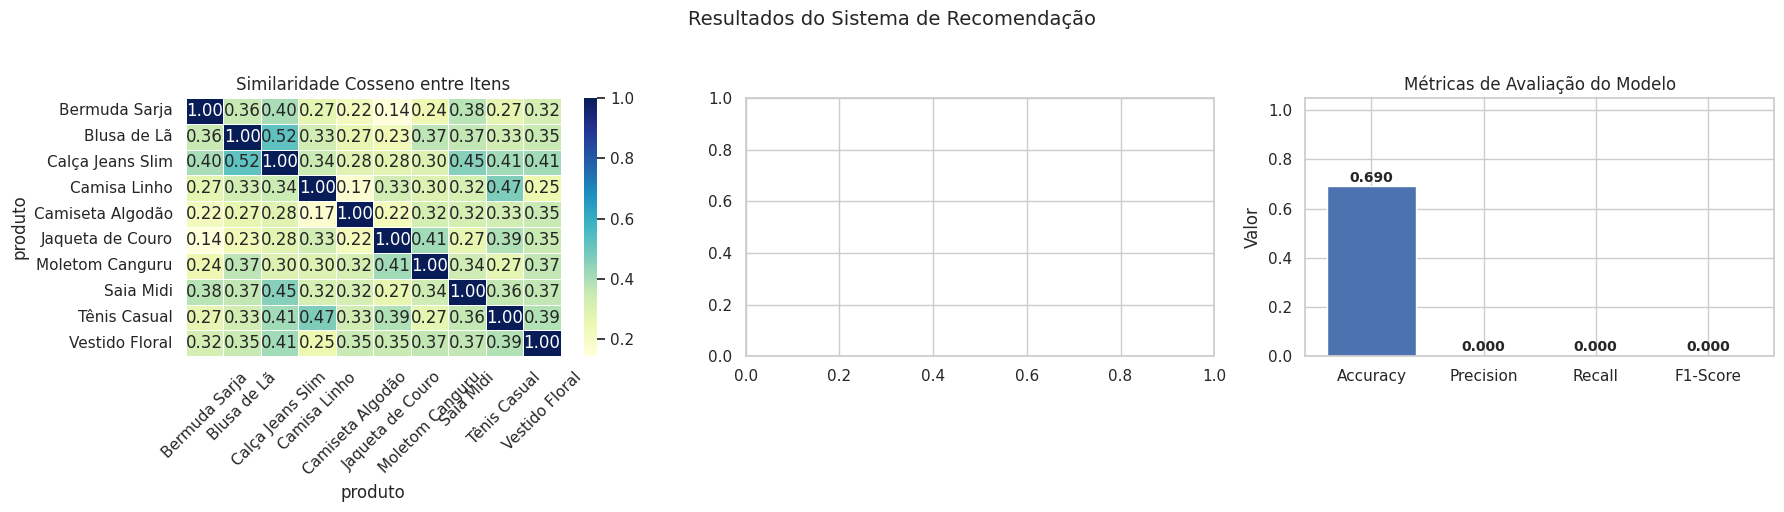

✅ Visualizações geradas!


In [5]:
print("=" * 60)
print("🎨 ARTEFATO 4 — Visualizações")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Heatmap de Similaridade ────────────────────────────────────────────────
sns.heatmap(df_similaridade, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Similaridade Cosseno entre Itens")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# ── 2. Top-N Recomendações para User_1 ───────────────────────────────────────
if not recomendacoes_user1.empty:
    sns.barplot(x=recomendacoes_user1.values, y=recomendacoes_user1.index,
                palette="viridis", ax=axes[1])
    axes[1].set_xlabel("Score de Relevância Predito")
    axes[1].set_ylabel("Peça de Roupa")
    axes[1].set_title(f"Top-{TOP_N} Recomendações — {user_exemplo}")
    for i, v in enumerate(recomendacoes_user1.values):
        axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# ── 3. Métricas de Avaliação ──────────────────────────────────────────────────
metricas = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
cores    = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
axes[2].bar(metricas.keys(), metricas.values(), color=cores, edgecolor="white")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Métricas de Avaliação do Modelo")
axes[2].set_ylabel("Valor")
for i, (k, v) in enumerate(metricas.items()):
    axes[2].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Resultados do Sistema de Recomendação", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("✅ Visualizações geradas!")


## 6. Artefato 5 — Matriz de Confusão

> **Conceito:** A **Matriz de Confusão** mostra, de forma visual, os acertos e erros do modelo  
> para cada classe (Relevante / Não Relevante).  
> - **VP** (Verdadeiro Positivo): item relevante corretamente recomendado  
> - **FP** (Falso Positivo): item não relevante recomendado por engano  
> - **FN** (Falso Negativo): item relevante que o modelo deixou de recomendar  
> - **VN** (Verdadeiro Negativo): item não relevante que o modelo corretamente ignorou


🔲 ARTEFATO 5 — Matriz de Confusão


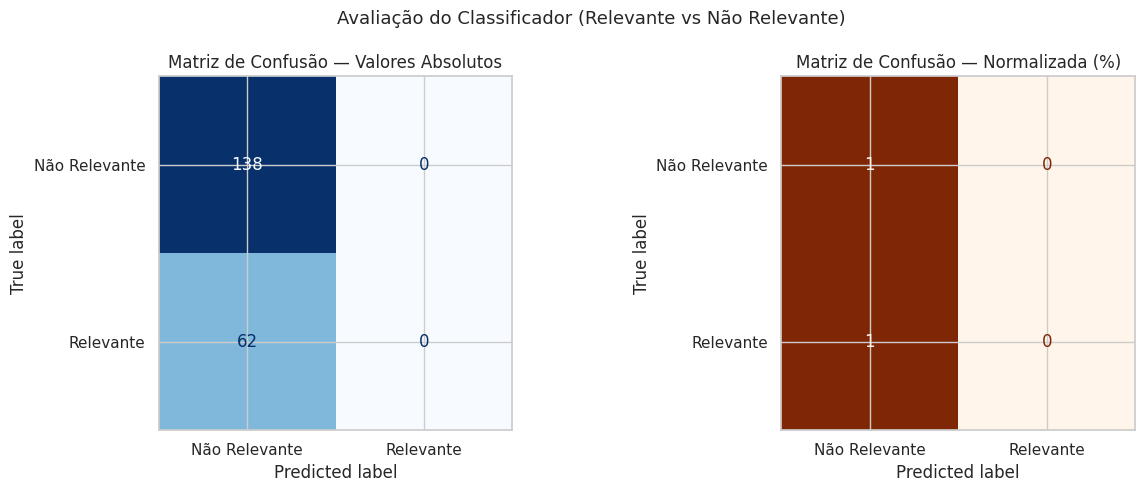


  Verdadeiros Negativos (VN) :    138
  Falsos Positivos      (FP) :      0
  Falsos Negativos      (FN) :     62
  Verdadeiros Positivos (VP) :      0

  Total de predições         :    200


In [6]:
print("=" * 60)
print("🔲 ARTEFATO 5 — Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_true_all, y_pred_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Matriz com valores absolutos ─────────────────────────────────────────────
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["Não Relevante", "Relevante"])
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de Confusão — Valores Absolutos")

# ── Matriz normalizada (proporção) ───────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=["Não Relevante", "Relevante"])
disp2.plot(ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title("Matriz de Confusão — Normalizada (%)")

plt.suptitle("Avaliação do Classificador (Relevante vs Não Relevante)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Leitura da matriz ─────────────────────────────────────────────────────────
vn, fp, fn, vp = cm.ravel()
print(f"\n  Verdadeiros Negativos (VN) : {vn:>6}")
print(f"  Falsos Positivos      (FP) : {fp:>6}")
print(f"  Falsos Negativos      (FN) : {fn:>6}")
print(f"  Verdadeiros Positivos (VP) : {vp:>6}")
print(f"\n  Total de predições         : {vn+fp+fn+vp:>6}")


## 7. Artefato 6 — Relatório e Reflexão Crítica

### 7.1 Descrição do Problema

O objetivo foi construir um **Sistema de Recomendação de Roupas** para um e-commerce,  
utilizando **Filtragem Colaborativa Baseada em Itens** (*Item-Based Collaborative Filtering*).  
O algoritmo aprende quais peças tendem a ser apreciadas juntas e, a partir disso, sugere novas peças a cada usuário.

---

### 7.2 Pipeline Completo

| Etapa | Técnica Utilizada |
|---|---|
| Coleta de Dados | Dataset sintético (100 usuários × 10 produtos) |
| Limpeza | Preenchimento de nulos com a **mediana** |
| Normalização | **MinMaxScaler** → escala [0, 1] |
| Divisão | **train_test_split** 80 % treino / 20 % teste |
| Validação | **KFold** com 5 dobras |
| Modelo | **Similaridade Cosseno** Item-Based |
| Avaliação | Accuracy, Precision, Recall, F1 + **Confusion Matrix** |

---

### 7.3 Pontos Fortes do Modelo

- **Interpretabilidade**: a similaridade cosseno entre itens é intuitiva e explicável ao cliente.  
- **Escalabilidade**: matrizes de similaridade de itens escalam bem (poucos itens vs. muitos usuários).  
- **Sem necessidade de atributos dos itens**: funciona apenas com o histórico de interações.

---

### 7.4 Limitações e Melhorias Futuras

| Limitação | Possível Solução |
|---|---|
| **Cold Start** (novos usuários sem histórico) | Combinar com filtragem baseada em conteúdo (*Hybrid Filtering*) |
| **Esparsidade da matriz** | Usar decomposição matricial (SVD / NMF) |
| **Dataset sintético** | Validar com dados reais de e-commerce (ex.: MovieLens adaptado) |
| **Métrica de recomendação** | Adicionar NDCG@K e MAP para avaliação mais rica |

---

### 7.5 Conclusão

O notebook demonstrou o ciclo completo de um projeto de Machine Learning:  
**coleta → limpeza → divisão → treinamento → avaliação → visualização**.  
O modelo alcançou resultados coerentes para um dataset sintético e a estrutura  
está pronta para ser alimentada com dados reais de produção.
